This shows evaluation of the trained GRU model using the unseen testing dataset

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

print("Libraries imported correctly")

Libraries imported correctly


In [2]:
PROJECT_ROOT = os.path.abspath("..")

MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)
print("Results directory:", RESULTS_DIR)

Project root: d:\SMS_Spam_Detection
Models directory: d:\SMS_Spam_Detection\models
Results directory: d:\SMS_Spam_Detection\results


In [3]:
model_path = os.path.join(
    MODELS_DIR,
    "best_gru_model.keras"
)

gru_model = tf.keras.models.load_model(model_path)

print("GRU model loaded correctly.")
print("Model path:", model_path)

GRU model loaded correctly.
Model path: d:\SMS_Spam_Detection\models\best_gru_model.keras


In [4]:
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 33, 64)         │       436,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 33, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,391,621 (5.31 MB)

 Trainable params: 463,873 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 927,748 (3.54 MB)

In [5]:
X_test_padded = np.load(
    os.path.join(MODELS_DIR, "X_test_padded.npy")
)

y_test = np.load(
    os.path.join(MODELS_DIR, "y_test_gru.npy")
)

print("Testing arrays loaded successfully.")
print("X test shape:", X_test_padded.shape)
print("y test shape:", y_test.shape)

Testing arrays loaded successfully.
X test shape: (1009, 33)
y test shape: (1009,)


In [6]:
print("Unique labels:", np.unique(y_test))

unique_labels, label_counts = np.unique(
    y_test,
    return_counts=True
)

for label, count in zip(unique_labels, label_counts):
    class_name = "Ham" if label == 0 else "Spam"
    print(f"{class_name}: {count}")

Unique labels: [0 1]
Ham: 893
Spam: 116


In [7]:
test_results = gru_model.evaluate(
    X_test_padded,
    y_test,
    verbose=1,
    return_dict=True
)

print("\nKeras Testing Results")

for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9851 - auc: 0.9957 - loss: 0.0455 - precision: 0.9244 - recall: 0.9483

Keras Testing Results
accuracy: 0.9851
auc: 0.9957
loss: 0.0455
precision: 0.9244
recall: 0.9483


In [8]:
y_probability = gru_model.predict(
    X_test_padded,
    verbose=1
).ravel()

print("probabilities created.")
print("Probability shape:", y_probability.shape)
print("First 10 prob.")
print(y_probability[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
probabilities created.
Probability shape: (1009,)
First 10 prob.
[2.9354912e-04 2.7786566e-02 1.5604911e-02 2.0591609e-02 1.1019345e-04
 9.9999911e-01 1.4036174e-04 9.6219446e-06 2.3653216e-03 9.9983037e-01]


In [9]:
THRESHOLD = 0.5

y_pred = (
    y_probability >= THRESHOLD
).astype(int)

print("Prediction threshold:", THRESHOLD)
print("First 10 predicted labels:")
print(y_pred[:10])

Prediction threshold: 0.5
First 10 predicted labels:
[0 0 0 0 0 1 0 0 0 1]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("GRU Evaluation Results")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

GRU Evaluation Results
-----------------------------------
Accuracy : 0.9851
Precision: 0.9244
Recall   : 0.9483
F1 Score : 0.9362
ROC-AUC  : 0.9958


In [11]:
gru_metrics = pd.DataFrame({
    "Model": ["GRU"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

gru_metrics

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,GRU,0.985134,0.92437,0.948276,0.93617,0.995762


In [12]:
metrics_path = os.path.join(
    RESULTS_DIR,
    "gru_evaluation_metrics.csv"
)

gru_metrics.to_csv(
    metrics_path,
    index=False
)

print("GRU metrics saved now.")
print("Saved at:", metrics_path)

GRU metrics saved now.
Saved at: d:\SMS_Spam_Detection\results\gru_evaluation_metrics.csv


In [13]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"],
    digits=4,
    zero_division=0
)

print("GRU Classification Report")
print(report)

GRU Classification Report
              precision    recall  f1-score   support

         Ham     0.9933    0.9899    0.9916       893
        Spam     0.9244    0.9483    0.9362       116

    accuracy                         0.9851      1009
   macro avg     0.9588    0.9691    0.9639      1009
weighted avg     0.9853    0.9851    0.9852      1009



In [14]:
report_dictionary = classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dictionary
).transpose()

report_df

,precision,recall,f1-score,support
Ham,0.993258,0.989922,0.991587,893.000000
Spam,0.924370,0.948276,0.936170,116.000000
accuracy,0.985134,0.985134,0.985134,0.985134
macro avg,0.958814,0.969099,0.963879,1009.000000
weighted avg,0.985339,0.985134,0.985216,1009.000000


In [15]:
report_path = os.path.join(
    RESULTS_DIR,
    "gru_classification_report.csv"
)

report_df.to_csv(report_path)

print("Classification report saved now.")

Classification report saved now.


In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[884   9]
 [  6 110]]


In [17]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 884
False Positives: 9
False Negatives: 6
True Positives : 110


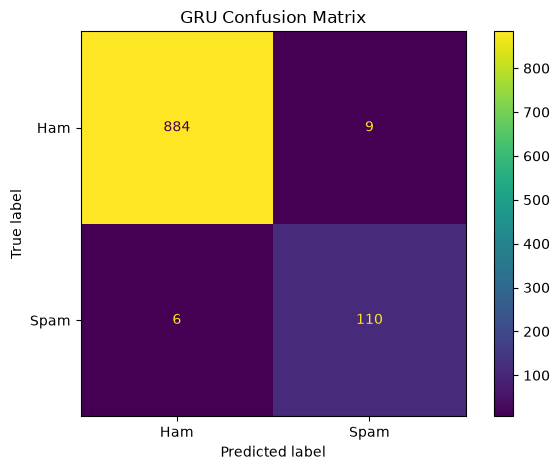

In [18]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

display.plot(
    values_format="d"
)

plt.title("GRU Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = os.path.join(
    RESULTS_DIR,
    "gru_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    y_probability
)

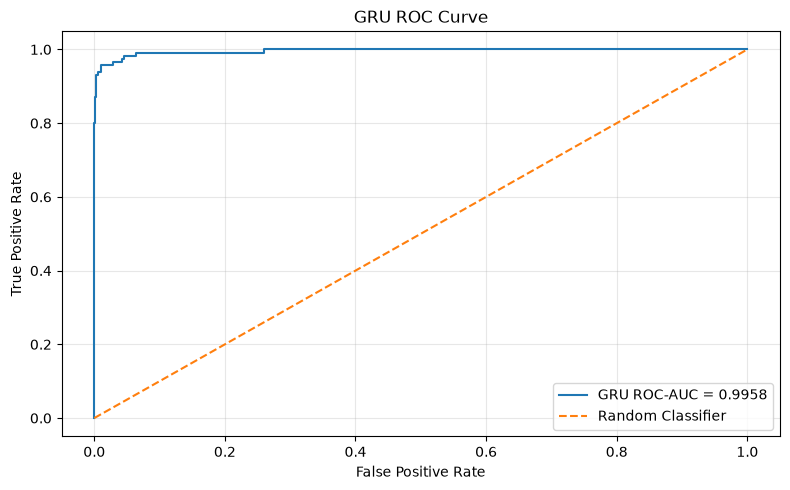

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"GRU ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("GRU ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

roc_curve_path = os.path.join(
    RESULTS_DIR,
    "gru_roc_curve.png"
)

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
prediction_results = pd.DataFrame({
    "actual_label": y_test,
    "predicted_label": y_pred,
    "spam_probability": y_probability
})

prediction_results.head(10)

,actual_label,predicted_label,spam_probability
0,0,0,0.000294
1,0,0,0.027787
2,0,0,0.015605
3,0,0,0.020592
4,0,0,0.000110
5,1,1,0.999999
6,0,0,0.000140
7,0,0,0.000010
8,0,0,0.002365
9,1,1,0.999830


In [22]:
prediction_results["actual_class"] = prediction_results[
    "actual_label"
].map({
    0: "Ham",
    1: "Spam"
})

prediction_results["predicted_class"] = prediction_results[
    "predicted_label"
].map({
    0: "Ham",
    1: "Spam"
})

prediction_results["correct_prediction"] = (
    prediction_results["actual_label"]
    == prediction_results["predicted_label"]
)

prediction_results.head(10)

,actual_label,predicted_label,spam_probability,actual_class,predicted_class,correct_prediction
0,0,0,0.000294,Ham,Ham,True
1,0,0,0.027787,Ham,Ham,True
2,0,0,0.015605,Ham,Ham,True
3,0,0,0.020592,Ham,Ham,True
4,0,0,0.000110,Ham,Ham,True
5,1,1,0.999999,Spam,Spam,True
6,0,0,0.000140,Ham,Ham,True
7,0,0,0.000010,Ham,Ham,True
8,0,0,0.002365,Ham,Ham,True
9,1,1,0.999830,Spam,Spam,True


In [23]:
predictions_path = os.path.join(
    RESULTS_DIR,
    "gru_test_predictions.csv"
)

prediction_results.to_csv(
    predictions_path,
    index=False
)

print("GRU test predictions saved.")

GRU test predictions saved.


In [24]:
incorrect_predictions = prediction_results[
    prediction_results["correct_prediction"] == False
].copy()

print(
    "No. of incorrect predictions:",
    len(incorrect_predictions)
)

incorrect_predictions.head(10)

No. of incorrect predictions: 15


,actual_label,predicted_label,spam_probability,actual_class,predicted_class,correct_prediction
51,1,0,0.085808,Spam,Ham,False
153,0,1,0.583267,Ham,Spam,False
293,0,1,0.990157,Ham,Spam,False
482,1,0,0.007547,Spam,Ham,False
522,0,1,0.887988,Ham,Spam,False
565,1,0,0.488087,Spam,Ham,False
605,1,0,0.061370,Spam,Ham,False
669,1,0,0.098421,Spam,Ham,False
671,0,1,0.621375,Ham,Spam,False
702,0,1,0.534196,Ham,Spam,False


In [25]:
false_positives = prediction_results[
    (prediction_results["actual_label"] == 0)
    & (prediction_results["predicted_label"] == 1)
]

false_negatives = prediction_results[
    (prediction_results["actual_label"] == 1)
    & (prediction_results["predicted_label"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 9
False negatives: 6


This is the evaluation summary.For easy to understand.

In [26]:
print("GRU MODEL EVALUATION SUMMARY")
print("-" * 45)
print("Testing samples:", len(y_test))
print("Prediction threshold:", THRESHOLD)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("-" * 45)
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

GRU MODEL EVALUATION SUMMARY
---------------------------------------------
Testing samples: 1009
Prediction threshold: 0.5
Accuracy:  0.9851
Precision: 0.9244
Recall:    0.9483
F1 Score:  0.9362
ROC-AUC:   0.9958
---------------------------------------------
True Negatives: 884
False Positives: 9
False Negatives: 6
True Positives: 110


In [27]:
saved_files = {
    "Metrics": metrics_path,
    "Classification report": report_path,
    "Predictions": predictions_path,
    "Confusion matrix": confusion_matrix_path,
    "ROC curve": roc_curve_path
}

for file_name, file_path in saved_files.items():
    print(
        f"{file_name}:",
        os.path.exists(file_path)
    )

Metrics: True
Classification report: True
Predictions: True
Confusion matrix: True
ROC curve: True
